In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import drive
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from collections import Counter
from xgboost import XGBClassifier
import shap
from IPython.display import Markdown, display

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
file_path = '/content/drive/MyDrive/tese André mg feuc/datasets/stress perguntas dataset/Stress Dataset.csv'
df = pd.read_csv(file_path)

# Data Cleaning
initial_shape = df.shape
df = df.drop_duplicates()
df = df.dropna()

print(f'Original dataset shape: {initial_shape}')
print(f'Dataset shape after cleaning: {df.shape}')
display(df.head())

Original dataset shape: (843, 26)
Dataset shape after cleaning: (816, 26)


,Gender,Age,Have you recently experienced stress in your life?,Have you noticed a rapid heartbeat or palpitations?,Have you been dealing with anxiety or tension recently?,Do you face any sleep problems or difficulties falling asleep?,Have you been dealing with anxiety or tension recently?.1,Have you been getting headaches more often than usual?,Do you get irritated easily?,Do you have trouble concentrating on your academic tasks?,...,Are you facing any difficulties with your professors or instructors?,Is your working environment unpleasant or stressful?,Do you struggle to find time for relaxation and leisure activities?,Is your hostel or home environment causing you difficulties?,Do you lack confidence in your academic performance?,Do you lack confidence in your choice of academic subjects?,Academic and extracurricular activities conflicting for you?,Do you attend classes regularly?,Have you gained/lost weight?,Which type of stress do you primarily experience?
0,0,20,3,4,2,5,1,2,1,2,...,3,1,4,1,2,1,3,1,2,Eustress (Positive Stress) - Stress that motiv...
1,0,20,2,3,2,1,1,1,1,4,...,3,2,1,1,3,2,1,4,2,Eustress (Positive Stress) - Stress that motiv...
2,0,20,5,4,2,2,1,3,4,2,...,2,2,2,1,4,1,1,2,1,Eustress (Positive Stress) - Stress that motiv...
3,1,20,3,4,3,2,2,3,4,3,...,1,1,2,1,2,1,1,5,3,Eustress (Positive Stress) - Stress that motiv...
4,0,20,3,3,3,2,2,4,4,4,...,2,3,1,2,2,4,2,2,2,Eustress (Positive Stress) - Stress that motiv...


In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

# Identify the target column
target_col = [c for c in df.columns if all(k in c.lower() for k in ['type', 'stress'])][0]
print(f'Target column identified: {target_col}')

# Flexible encoding: search for keywords instead of exact string match
def encode_stress(val):
    val_lower = str(val).lower()
    if 'distress' in val_lower:
        return 0
    elif 'no stress' in val_lower:
        return 1
    elif 'eustress' in val_lower:
        return 2
    return np.nan

df_clean = df.copy()
df_clean['stress_type_encoded'] = df_clean[target_col].apply(encode_stress)

# Check if mapping worked
counts = df_clean['stress_type_encoded'].value_counts(dropna=False)
print("Encoded value counts:\n", counts)

# 1. Binary target: 0 = Distress, 1 = Rest (No Stress / Eustress)
y_binary = df_clean['stress_type_encoded'].apply(lambda x: 0 if x == 0 else 1)

# 2. Select numeric features
X = df_clean.select_dtypes(include=[np.number]).drop(columns=['stress_type_encoded'], errors='ignore')

# Ensure we have both classes before splitting
if len(np.unique(y_binary)) < 2:
    raise ValueError(f"Still only found one class in the binary target. Unique values in column: {df_clean[target_col].unique()}")

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

# 3. Apply SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_bin, y_train_bin)

print(f'Distribution after SMOTE: {Counter(y_train_res)}')
print('Data preparation complete. Please run the next cells to train the models.')

Target column identified: Which type of stress do you primarily experience?
Encoded value counts:
 stress_type_encoded
2    745
1     42
0     29
Name: count, dtype: int64
Distribution after SMOTE: Counter({1: 629, 0: 629})
Data preparation complete. Please run the next cells to train the models.



--- Logistic Regression Results ---


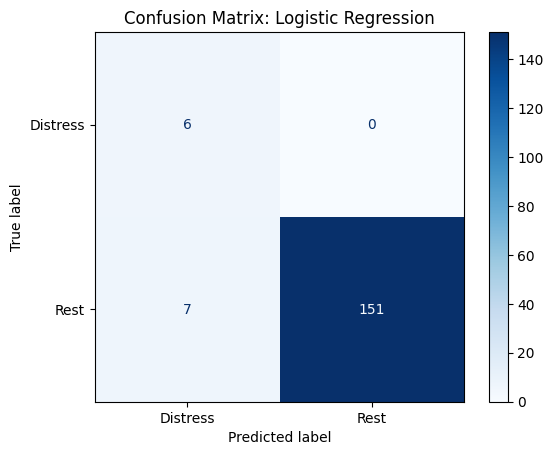


--- Random Forest Results ---


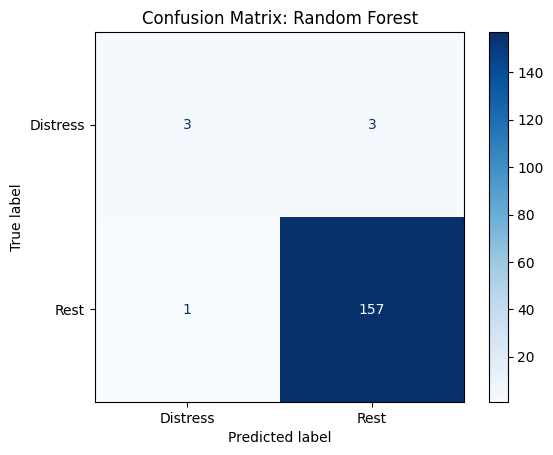


--- XGBoost Results ---


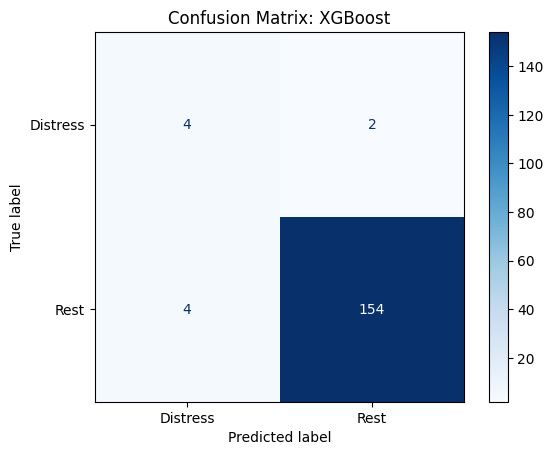

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results_list = []

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test_bin)

    report = classification_report(y_test_bin, y_pred, output_dict=True)

    results_list.append({
        'Model': name,
        'F1-macro': report['macro avg']['f1-score'],
        'Precision(Distress)': report['0']['precision'],
        'Recall(Distress)': report['0']['recall'],
        'Accuracy': report['accuracy']
    })

    print(f'\n--- {name} Results ---')
    cm = confusion_matrix(y_test_bin, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Distress', 'Rest'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

In [12]:
# 6. Comparative Table
results_df = pd.DataFrame(results_list)
display(Markdown("### Model Comparison (Distress Detection)"))
display(results_df)

### Model Comparison (Distress Detection)

,Model,F1-macro,Precision(Distress),Recall(Distress),Accuracy
0,Logistic Regression,0.804463,0.461538,1.000000,0.957317
1,Random Forest,0.793711,0.750000,0.500000,0.975610
2,XGBoost,0.776160,0.500000,0.666667,0.963415


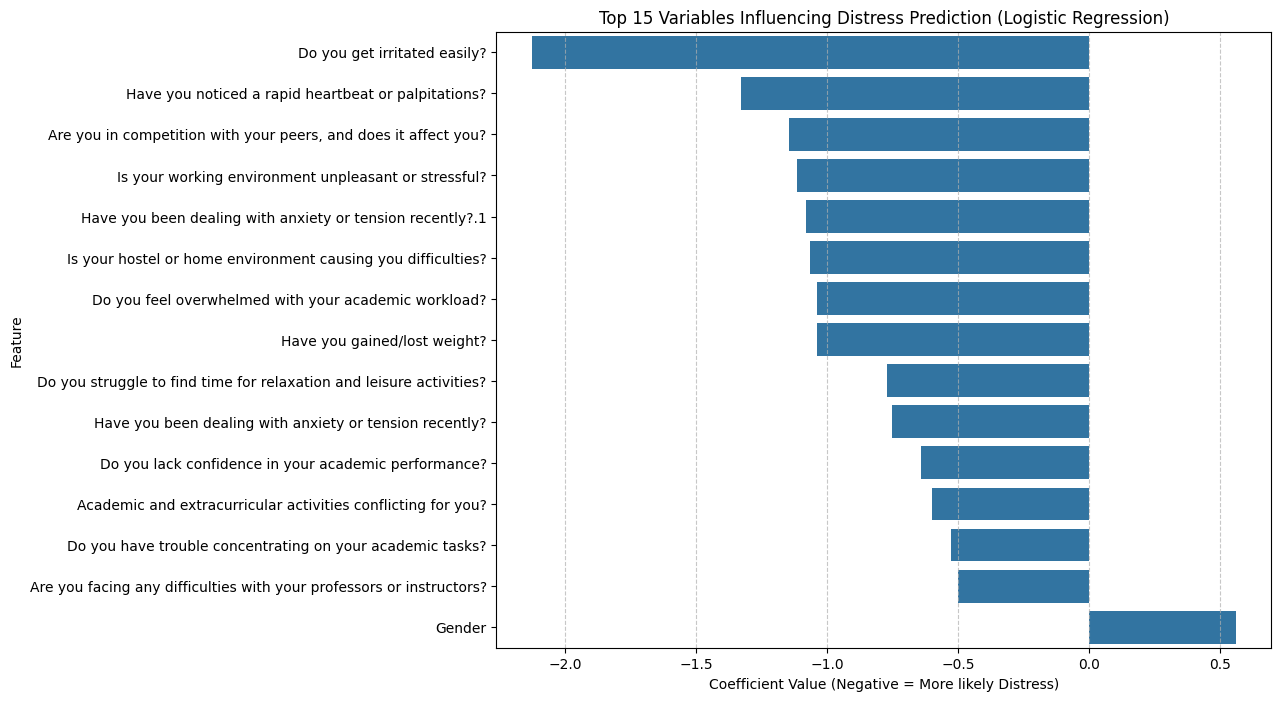

In [13]:
import seaborn as sns
# 7. Logistic Regression Feature Importance
lr_model = models['Logistic Regression']
# Model must be fitted to have coef_
coefficients = lr_model.coef_[0]
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': coefficients})
feature_importance['AbsImportance'] = feature_importance['Importance'].abs()
top_15 = feature_importance.sort_values(by='AbsImportance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_15.sort_values(by='Importance'))
plt.title('Top 15 Variables Influencing Distress Prediction (Logistic Regression)')
plt.xlabel('Coefficient Value (Negative = More likely Distress)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()